In [ ]:
from google.colab import files
uploaded = files.upload()

Saving synthetic_health_water_dataset_1000.csv to synthetic_health_water_dataset_1000.csv


Columns in dataset: Index(['date', 'village_id', 'latitude', 'longitude', 'age_group',
       'symptom_diarrhea', 'symptom_vomiting', 'symptom_fever',
       'water_turbidity', 'water_ph', 'water_temp', 'tds', 'coliform_present',
       'rainfall_mm', 'confirmed_outbreak'],
      dtype='object')
Categorical columns: Index(['date', 'village_id', 'age_group'], dtype='object')
Numerical columns: Index(['latitude', 'longitude', 'symptom_diarrhea', 'symptom_vomiting',
       'symptom_fever', 'water_turbidity', 'water_ph', 'water_temp', 'tds',
       'coliform_present', 'rainfall_mm', 'confirmed_outbreak'],
      dtype='object')


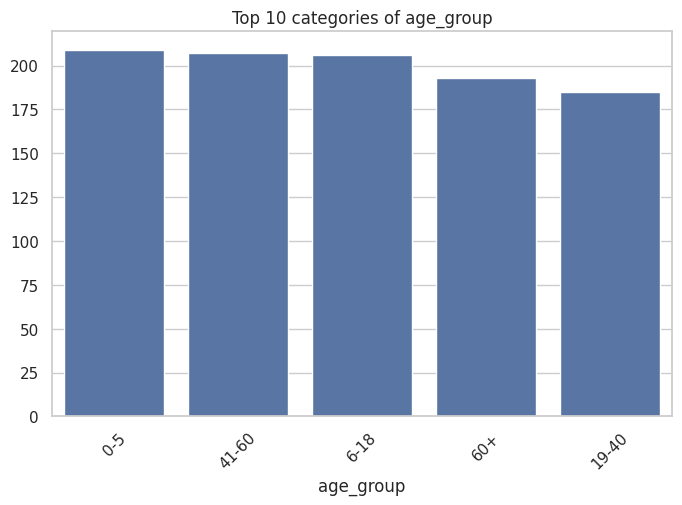

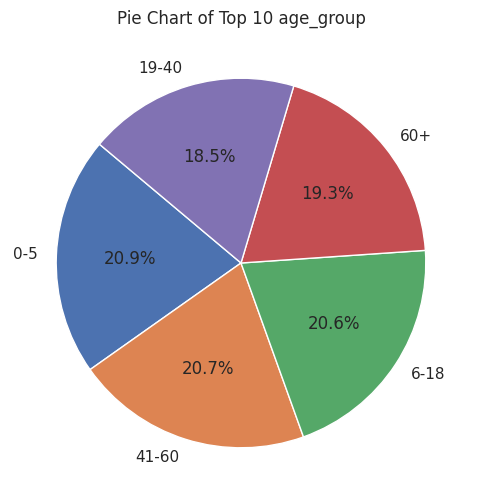

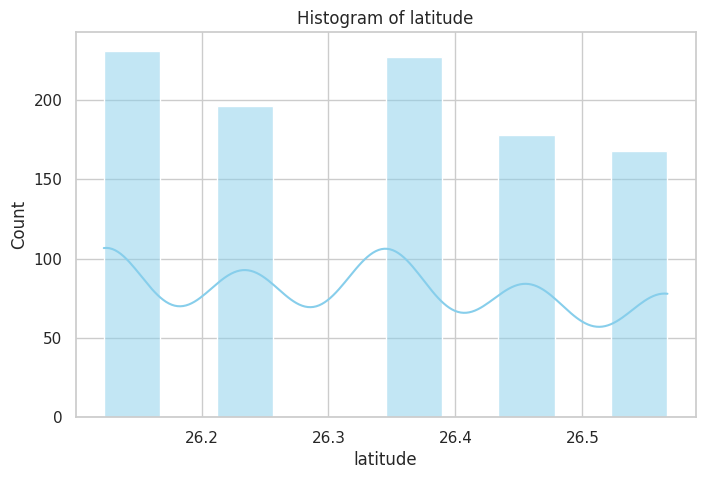

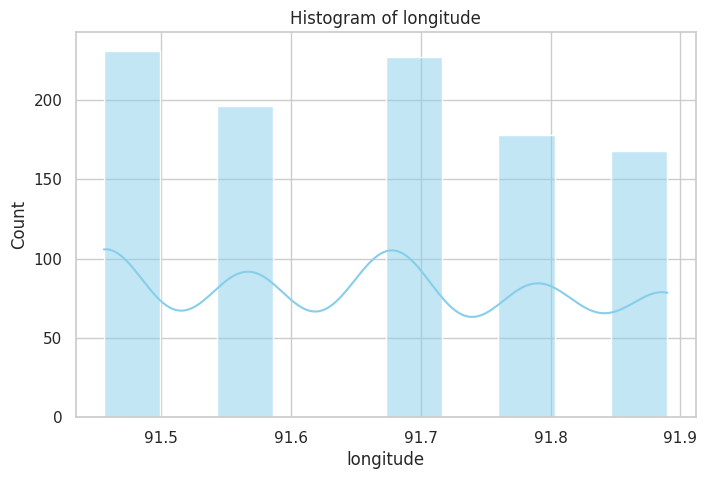

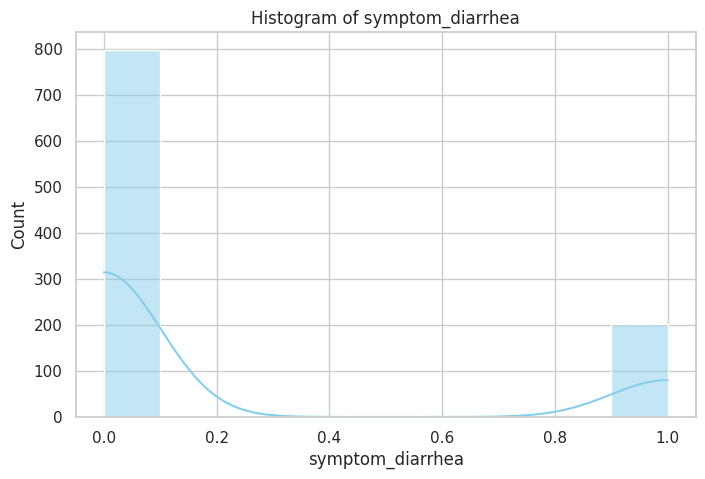

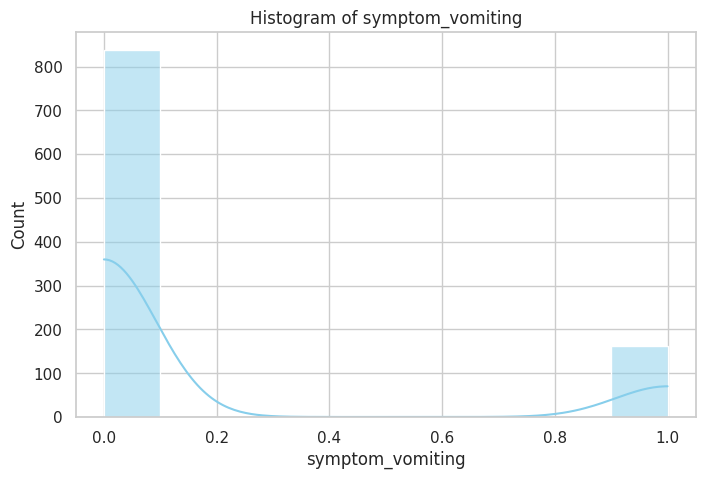

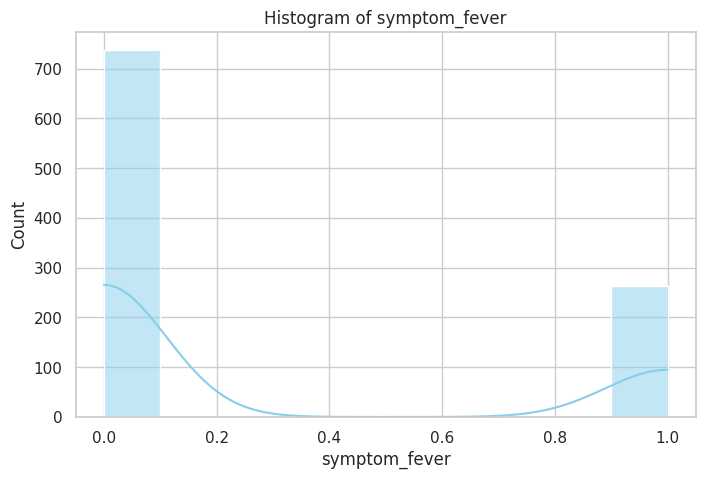

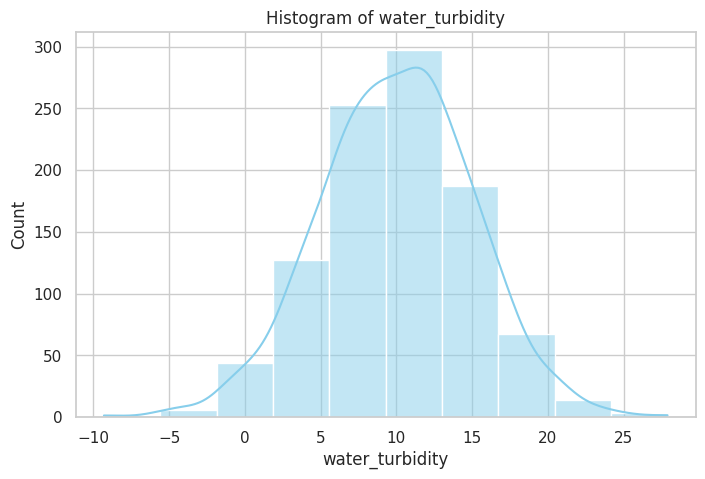

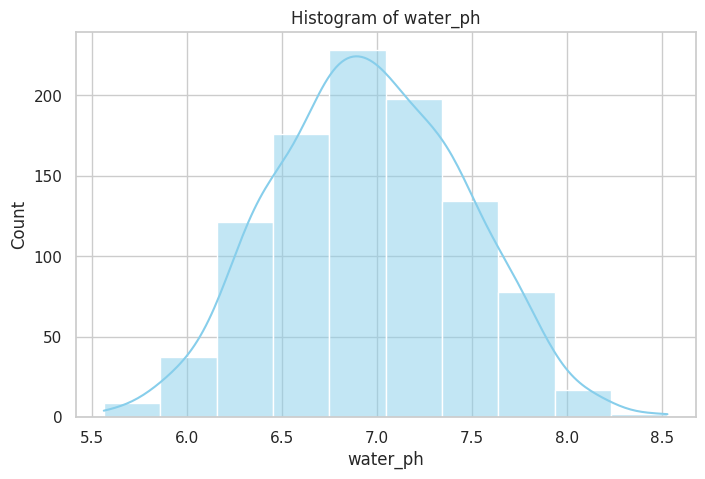

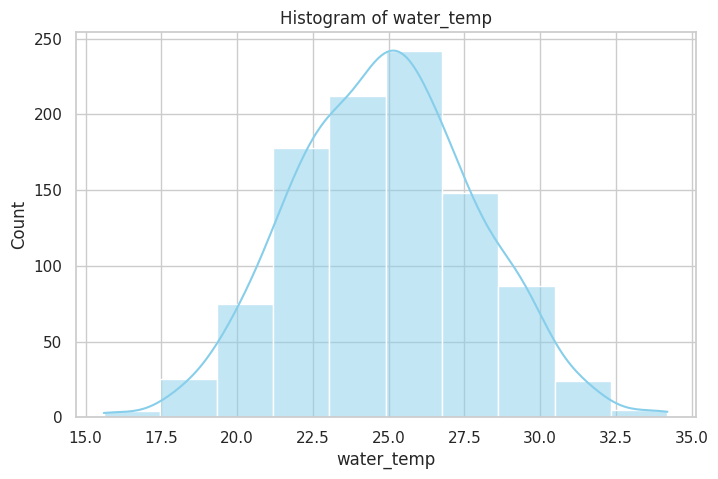

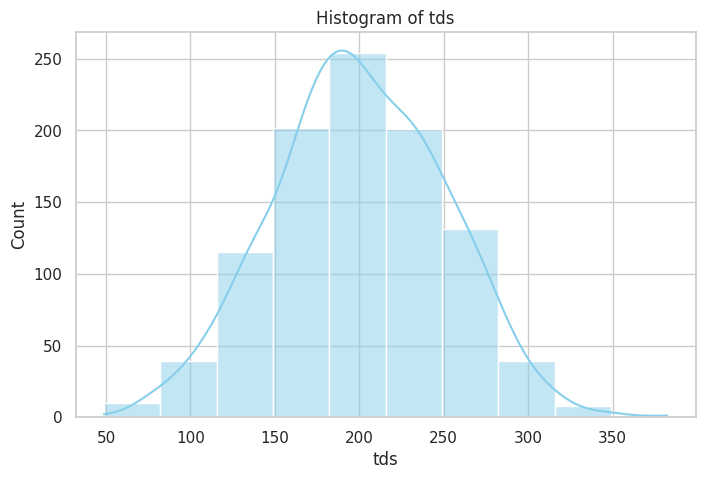

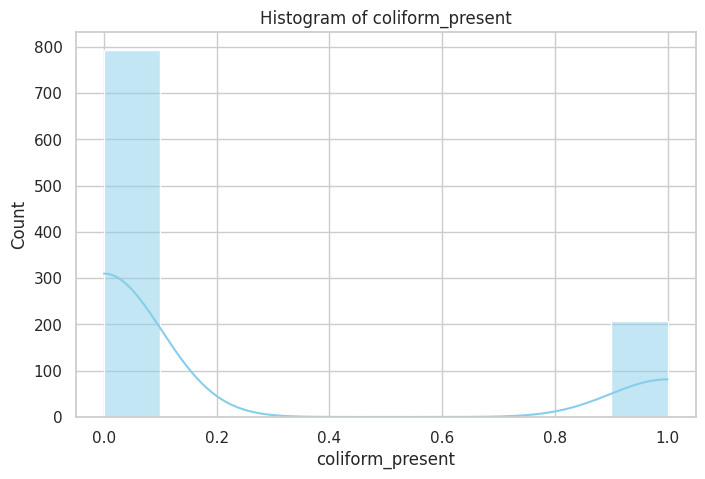

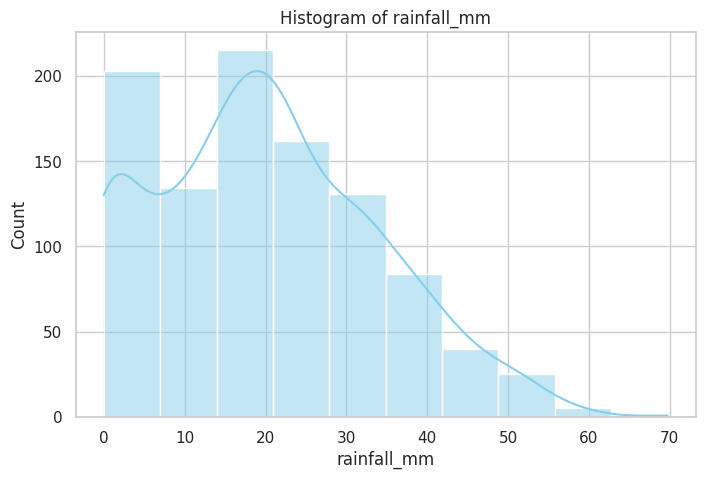

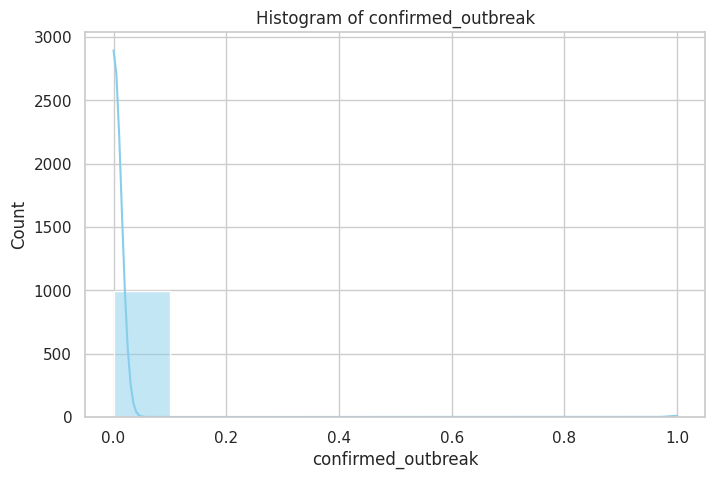

Linear Regression Results:
Mean Squared Error: 0.009817077531924113
R2 Score: 0.008376006876352093


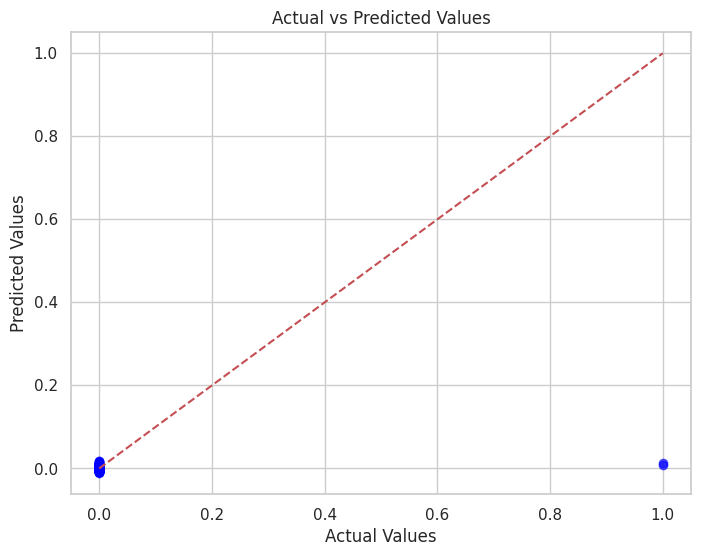

In [ ]:
 # -----------------------------
# STEP 0: IMPORT LIBRARIES
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid")

# -----------------------------
# STEP 1: LOAD DATASET
# -----------------------------
df = pd.read_csv("synthetic_health_water_dataset_1000.csv")
print("Columns in dataset:", df.columns)
df.head()

# -----------------------------
# STEP 2: DETECT COLUMN TYPES
# -----------------------------
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

# -----------------------------
# STEP 3: VISUALIZATION
# -----------------------------
top_n = 10  # limit for top categories
skip_cols = ['date', 'village_id']  # skip extremely high-cardinality columns

# Bar plots for categorical columns (top N only)
for col in categorical_cols:
    if col in skip_cols:
        continue
    counts = df[col].value_counts().nlargest(top_n)
    plt.figure(figsize=(8,5))
    sns.barplot(x=counts.index, y=counts.values)
    plt.title(f"Top {top_n} categories of {col}")
    plt.xticks(rotation=45)
    plt.show()

# Pie charts for categorical columns (top N only)
for col in categorical_cols:
    if col in skip_cols:
        continue
    counts = df[col].value_counts().nlargest(top_n)
    plt.figure(figsize=(6,6))
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
    plt.title(f"Pie Chart of Top {top_n} {col}")
    plt.show()

# Histograms for numerical columns
for col in numerical_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], bins=10, kde=True, color='skyblue')
    plt.title(f"Histogram of {col}")
    plt.show()

# -----------------------------
# STEP 4: PREPROCESS DATA FOR REGRESSION
# -----------------------------
# Fill missing numerical values
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

# Encode categorical variables (drop first to avoid multicollinearity)
df = pd.get_dummies(df, drop_first=True)

# -----------------------------
# STEP 5: DEFINE TARGET & FEATURES
# -----------------------------
target_column = 'confirmed_outbreak'  # target column, change if needed
if target_column not in df.columns:
    raise ValueError(f"{target_column} not found in dataset columns!")

X = df.drop(target_column, axis=1)
y = df[target_column]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# STEP 6: LINEAR REGRESSION
# -----------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Linear Regression Results:")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# -----------------------------
# STEP 7: PLOT ACTUAL VS PREDICTED
# -----------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()
